## Task1 : Iris Flower Classification

Use measurements of **Iris flowers** (setosa, versicolor, virginica) as input data.

- Train a **machine learning model** to classify the species based on these measurements.
- Use libraries like **Scikit-learn** for easy dataset access and model building.
- Evaluate the model’s **accuracy and performance** using test data.
- Understand **basic classification concepts** in machine learning.

**Import Libraries**

In [95]:
# Import basic labraries which EDA and Visualizations
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore all Warnings
import warnings
warnings.filterwarnings('ignore')

# For Data labeling library(Covert categorical val into numeric val)
from sklearn.preprocessing import LabelEncoder

# for Data splitting into train and test
from sklearn.model_selection import train_test_split

# Import Base Model's libraries 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Import Classification Model Evaluation library
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix 

In [59]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabh00007/iriscsv")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\saurabh00007\iriscsv\versions\1


download dataset from kaggel to system folder

**Load Dataset**

In [60]:

# Correct way to read the CSV file
iris_data = pd.read_csv(f"{path}/Iris.csv")

print(iris_data.head())
print('\nShape of Data:',iris_data.shape)

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Shape of Data: (150, 6)


In [160]:
iris_data.sample(7)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
70,71,5.9,3.2,4.8,1.8,1
101,102,5.8,2.7,5.1,1.9,2
128,129,6.4,2.8,5.6,2.1,2
140,141,6.7,3.1,5.6,2.4,2
65,66,6.7,3.1,4.4,1.4,1
60,61,5.0,2.0,3.5,1.0,1
21,22,5.1,3.7,1.5,0.4,0


**Exploratory Data Analysis(EDA)**

In [62]:
# check info of data
iris_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


As we observed that there is no null values in data

with correct dtypes

In [63]:
# Statiscal analysis
iris_data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [64]:
# check duplicated values
print("\nno of duplicate values in data:",iris_data.duplicated().sum())


no of duplicate values in data: 0


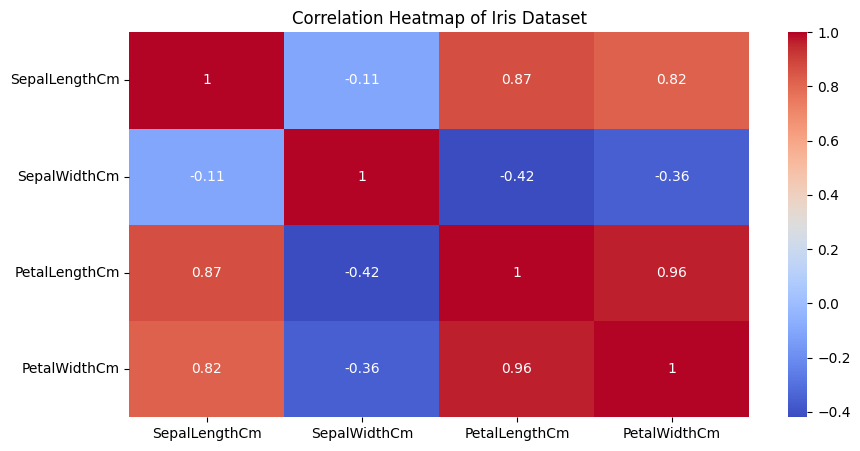

In [65]:
# lets correlation between col's
numeric_col = iris_data.drop(['Id', 'Species'], axis = 1)

plt.figure(figsize = (10,5))

sns.heatmap(numeric_col.corr(), annot = True, cmap = 'coolwarm')

plt.title('Correlation Heatmap of Iris Dataset')

plt.show()

- The correlation heatmap shows the relationship between different flower features. 
- PetalLength and PetalWidth have a very strong `positive correlation (0.96)`, indicating that larger petals tend to be both longer and wider. 
- SepalLength also shows `strong positive correlation` with petal measurements.
- `SepalWidth has weak or negative correlations` with other variables. 
- This suggests petal features are more important for distinguishing Iris species.

let's convert catogerical values into numeric values for better understanding of model's

In [66]:
le = LabelEncoder()

for cols in iris_data.columns:
    if iris_data[cols].dtypes == 'object':
        iris_data[cols] = le.fit_transform(iris_data[cols])

In [68]:
iris_data.Species.unique()

array([0, 1, 2])

Lets Divide data into independent features and dependent feature

In [69]:
x = iris_data.drop(['Id', 'Species'], axis = 1) # Id is column is not useful for prediction

y = iris_data['Species']

checking weather data is `balance or imbalance`

In [70]:
iris_data['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [71]:
# independent features
x.head()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [72]:
# dependent feature
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 150, dtype: int64

**Train Test Split**

In [73]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size = 0.20, random_state = 42)

print('Shape of X_train :', X_train.shape)

print('Shape of X_test :', X_test.shape)

Shape of X_train : (120, 4)
Shape of X_test : (30, 4)


**Model Buliding**

**Logistic Regression**

In [122]:
model_log = LogisticRegression()

# Train and test the model
model_log.fit(X_train,Y_train)

# Predict the values 
y_pred_log = model_log.predict(X_test);

In [123]:
print("Predicted values :",y_pred_log)

Predicted values : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [124]:
print('Accuracy_score :',accuracy_score(Y_test, y_pred_log)*100)

Accuracy_score : 100.0


Our model get `100 percent Accuracy score` means there is chance of `overfitting`

let's check train and test score results of `X(Independent) and Y(dependent) set's`

In [125]:
print('Train Accuracy :', model_log.score(X_train, Y_train)*100)
print('Test Accuracy :', model_log.score(X_test, Y_test)*100)

Train Accuracy : 97.5
Test Accuracy : 100.0


X and Y train test results score are almost similar values so our model `not overfitted`.

`Since our dataset is small and very clean, so getting near perfect accuracy is common`.

let's visulaize the predicted results

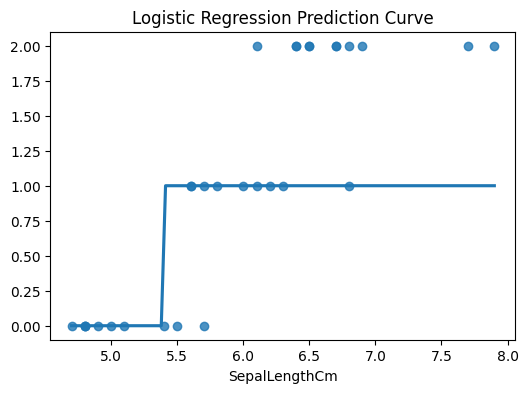

In [126]:
plt.figure(figsize=(6,4))

sns.regplot(
    x=X_test.iloc[:,0],   # choose one feature
    y=y_pred_log,
    logistic=True,
    ci=None
)

plt.title("Logistic Regression Prediction Curve")

plt.show()

in Above plot we observed that three different classes are separated by the line

**Model Evaluation**

In [127]:

def plot_confusion_matrix(Y_test, y_pred):

    cm = confusion_matrix(Y_test, y_pred_log)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

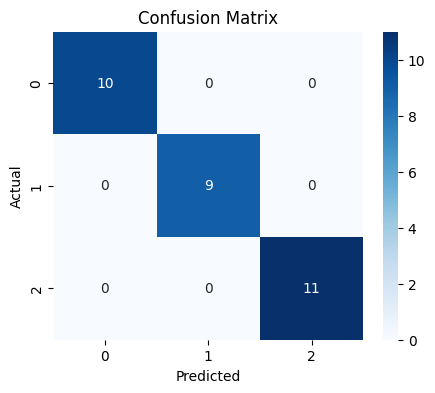

In [128]:
plot_confusion_matrix(Y_test, y_pred_log)

Here confusion matrix represents

- `Class 0(Setosa)` Actual samples = 10

predicted 10 means All predictions correct

- `class 1(Versicolor)` Actual samples = 9 

predicted 11 means All predictions correct

- `class 2(Virginica)` Actual samples = 11

predicted 11 means All predictions correct

Our matrix contains `all off-diagonal values = 0`

so, there is no misclassification, our model predicted every test samples correctly

In [93]:
print("Classification Report :\n", classification_report(Y_test, y_pred))

Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



As we see in classification report `precision, recall, f1-score` all get 1 means perfect testing results occured

**Decision Tree Classifier**

In [129]:
model_dtc = DecisionTreeClassifier()

model_dtc.fit(X_train, Y_train);

y_pred_dtc = model_dtc.predict(X_test)

In [130]:
print("Accuracy_score :", accuracy_score(Y_test, y_pred_dtc)*100)

Accuracy_score : 100.0


**Model Evaluation**

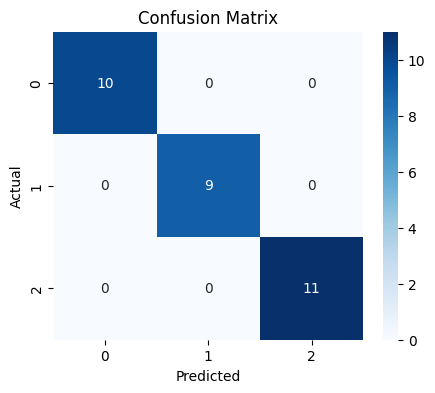

In [131]:
plot_confusion_matrix(Y_test, y_pred_dtc)

In [132]:
print("classification Report :\n", classification_report(Y_test, y_pred_dtc))

classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Here decision also predicted accurate values because of data is small

**Random Forest Classifier**

In [133]:
model_rfc = RandomForestClassifier(n_estimators = 100, random_state = 42)

model_rfc.fit(X_train, Y_train);

y_pred_rfc = model_rfc.predict(X_test)

In [134]:
print("Accuracy_score :", accuracy_score(Y_test, y_pred_rfc)*100)

Accuracy_score : 100.0


**Model_Evaluation**

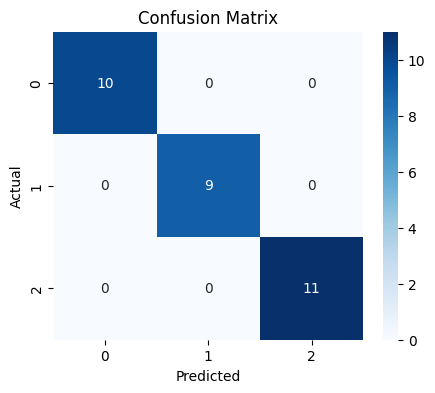

In [135]:
plot_confusion_matrix(Y_test, y_pred_rfc)

In [136]:
print('Classification Report :\n', classification_report(Y_test, y_pred_rfc))

Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Support Vector Classifier**

In [144]:
model_svc = SVC(kernel = 'rbf')

model_svc.fit(X_train, Y_train);

y_pred_svc = model_svc.predict(X_test)

In [145]:
print("Accuracy Score :", accuracy_score(Y_test, y_pred_svc)*100)

Accuracy Score : 100.0


In [146]:
model_svc = SVC(kernel = 'linear')

model_svc.fit(X_train, Y_train);

y_pred_svc = model_svc.predict(X_test)

In [147]:
print("Accuracy Score :", accuracy_score(Y_test, y_pred_svc)*100)

Accuracy Score : 100.0


In [148]:
model_svc = SVC(kernel = 'poly')

model_svc.fit(X_train, Y_train);

y_pred_svc = model_svc.predict(X_test)

In [149]:
print("Accuracy Score :", accuracy_score(Y_test, y_pred_svc)*100)

Accuracy Score : 100.0


**Model Evaluation**

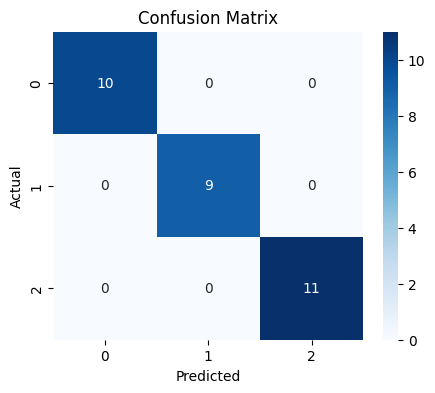

In [141]:
plot_confusion_matrix(Y_test, y_pred_svc)

In [143]:
print("Classification Report :\n", classification_report(Y_test,y_pred_svc))

Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



here we perform one evaluation only because all three kernel's gives similar accuracy score

**K-Nearest Neighbors( KNN )**

In [151]:
model_knn = KNeighborsClassifier()

model_knn.fit(X_train, Y_train);

y_pred_knn = model_knn.predict(X_test)

In [152]:
print("Accuracy Score :", accuracy_score(Y_test, y_pred_knn)*100)

Accuracy Score : 100.0


**Model_Evaluation**

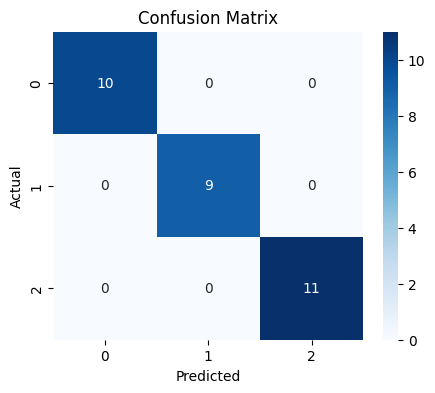

In [153]:
plot_confusion_matrix(Y_test, y_pred_knn)

In [154]:
print("Classification Report :\n", classification_report(Y_test,y_pred_knn))

Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Here we are doing model comparsion based on accuracy score

However all model gives similar Accuracy score but just do look for it

**Model Comparsion**

In [158]:
models = {
    'Logistic Regression': model_log.score(X_test, Y_test)*100,
    'Decision Tree Classifier': model_dtc.score(X_test, Y_test)*100,
    'Random Forest Classifier': model_rfc.score(X_test, Y_test)*100,
    'SVC': model_svc.score(X_test, Y_test)*100,
    'KNN': model_knn.score(X_test, Y_test)*100
}

for model, score in models.items():
    print(model, ":", score)

Logistic Regression : 100.0
Decision Tree Classifier : 100.0
Random Forest Classifier : 100.0
SVC : 100.0
KNN : 100.0


**Final Conclusion:** 
    
   - we performed `Logistic, Decision Tree, Random Forest, SVC and KNN` which are baseline models.
   - here this model's performed well and `gain 100% accuracy score`
   - we get 100% because our dataset is small.
   
Similarly Model Evaluation we performed as `Confusion matrix and classification report`.

   - All baseline model performed similar evaluation
   - model predicts everything correctly